# **EXPLORATORY ANALYSIS**

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deskaygraphics/ML_LULC/blob/main/Machine_Learning_Class_Project.ipynb)

Certain libraries need to be installed every time you run this Colab notebook, as they are not saved after the initial installation. The following script ensures these essential libraries are installed for the project.

In [ ]:
%pip install rasterio

In [ ]:
%pip install leafmap

***Loading and Preparing the Dataset***

**libraries for reading the data**

## Project Data

In this project, we are working with Sentinel-2 raster data, which includes all its bands and derived indices such as:

- **Normalized Difference Vegetation Index (NDVI)**
- **Normalized Difference Water Index (NDWI)**
- **Normalized Difference Built-up Index (NDBI)**

Additionally, we are incorporating their corresponding geometries. This means we are dealing with both raster and vector data types.

To effectively handle these data types, we will utilize the following libraries:
- **`rasterio`** for reading and processing raster data
- **`geopandas`** for working with vector data (geojson)
- **`leafmap`** for visualizing the vector and raster data
- **`numpy`** handle the image as numeric
- **`matplotlib.pyplot`** use to visualise the image


In [ ]:
import rasterio as rio
import leafmap
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

This script is used to load the data from the local computer. This one below is the reading of the jeojson file containing the satellite band and the indices.

In [ ]:
from google.colab import files

uploaded = files.upload()

Reading the data with the Geopandas library

In [ ]:
Bands = gpd.read_file("Bands_Indices_Sample_Data.geojson")
Bands

Separating the longitude and latitude from the geometry

In [ ]:
# Extract latitude and longitude from the geometry column
Bands["Latitude"] = Bands.geometry.y
Bands["Longitude"] = Bands.geometry.x

# Drop the geometry column

Bands

In [ ]:
from google.colab import files

uploaded = files.upload()


# Visualizing Sentinel-2 Data: RGB Image

#### **Loading the Sentinel-2 Data**
- Use the `rasterio` library to open the Sentinel-2 raster file (`sentinel2_2024cc30.tif`).
- Read the data into a variable `sentinel_image`, which contains:
  - **Bands**: Stored in the first dimension.
  - **Spatial Dimensions**: Rows and columns in the remaining dimensions.

---

#### **Reformatting the Data**
- **Why Transpose?**
  - Sentinel-2 data is initially stored as `(bands, rows, columns)`.
  - Transposing reorganizes it into `(rows, columns, bands)` for easier manipulation.
- Transposition ensures proper alignment of the data for visualization.

---

#### **Extracting the RGB Bands**
- Sentinel-2 provides multiple bands. For RGB visualization:
  - **Red**: Band 4
  - **Green**: Band 3
  - **Blue**: Band 2
- Extract these bands individually from the transposed image.

---

#### **Creating the RGB Image**
- Combine the red, green, and blue bands using `np.dstack()`.
- This forms an RGB composite image.

---

#### **Adjusting for Visualization**
- Sentinel-2 data often has high intensity values. To enhance visual contrast:
  - Multiply the RGB image by a **scaling factor** (2.5 in this case).
- This makes the image visually interpretable.

---

#### **Displaying the Image**
- Use `matplotlib` to plot the RGB image:
  - **Set the Figure Size**: `20x20 inches` for better detail.
  - **Display the Image**: Use `plt.imshow()` to show the scaled image.
  - **Clean Presentation**: `plt.axis('off')` removes axe.


In [ ]:
#
sentinel2 = rio.open("sentinel2_2024cc30.tif")
sentinel_image = sentinel2.read()

# Transpose the sentinel image to get the correct dimensions
sentinel_image = sentinel_image.transpose(1, 2, 0)

# Extract the red, green, and blue bands
red = sentinel_image[:, :, 3]
green = sentinel_image[:, :, 2]
blue = sentinel_image[:, :, 1]

# Stack the bands to create an RGB image
rgb = np.dstack((red, green, blue))

# Plot the RGB image with an appropriate scaling factor
plt.figure(figsize=[20, 20])
plt.imshow(rgb * 2.5)  # Adjust the scaling factor as needed
plt.axis("off")
plt.show()

***Visualizing the sample Point***

The script below makes use of leafmap library showing the training and testing sample point.

In [ ]:
m = leafmap.Map(center=[30.451189416235763, -91.17734163717974], zoom=13)
m.add_points_from_xy(Bands, x="Longitude", y="Latitude")
m

***Visualising Satellite Data and the Training samples together***

**Import Statements:**
   - `ListedColormap` and `matplotlib.pyplot` are imported for custom color mapping and visualization.
   - `rasterio.plot` is used for handling and plotting raster data.

**Custom Colormap:**
   - `ListedColormap` is created with three colors: `'blue'`, `'yellow'`, and `'green'`, representing categories in the dataset.

**Figure Setup:**
   - A `matplotlib` figure and axis are created with a size of 20x20 inches using `plt.subplots()`.

**Plotting GeoDataFrame:**
   - `gdf.plot()` visualizes the GeoDataFrame (`gdf`) using the `'Class'` column, which is assumed to contain categorical data.
   - The `cmap` is applied for the color scheme, and the legend is turned off with `legend=False`.

**Hiding Axes:**
   - `ax.axis('off')` removes axis lines and labels for a cleaner map visualization.

**Raster Data Visualization:**
   - `rplot.show()` plots a raster dataset (`rgb`) after transposing its dimensions for compatibility (`transpose([2,0,1])`).
   - The raster values are scaled (`*4`) for visualization purposes.
   - The plot aligns with the Sentinel-2 dataset's spatial reference (`transform=sentinel2.transform`) and is overlaid on the same axis (`ax=ax`).


In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import rasterio.plot as rplot

cmap = ListedColormap(["blue", "yellow", "green"])
fig, ax = plt.subplots(figsize=(20, 20))
Bands.plot(column="Class", categorical=True, cmap=cmap, legend=False, ax=ax)
ax.axis("off")
rplot.show(rgb.transpose([2, 0, 1]) * 4, transform=sentinel2.transform, ax=ax)




- **Mapping Definition**:
  - A dictionary `class_mapping` is created to translate numeric class labels (1, 2, 3) into meaningful descriptions ('waterbody', 'built_up', and 'bareland').

- **Adding Class Labels**:
  - A new column 'Class_Label' is added to the GeoDataFrame `gdf`. The `map` function replaces each numeric identifier in the 'Class' column with its corresponding descriptive label from the `class_mapping` dictionary.

- **Displaying the Data**:
  - The `head()` method is called on `gdf` to display the first five rows of the updated GeoDataFrame, providing a quick overview of the newly added labels alongside the existing data.


In [ ]:
# Define the mapping
class_mapping = {1: "waterbody", 2: "built_up", 3: "bareland"}

# Add a new column 'Class_Label' based on the mapping
Bands["Class_Label"] = Bands["Class"].map(class_mapping)

# Display the first few rows of the data
Bands.head()

***Checking for Missing Values***

**Checking for Missing Values**
   - The `.isnull()` method is applied to the `Bands` DataFrame to identify missing (null) values in each column.
   - `.sum()` is used to calculate the total number of missing values for each column.

**Storing the Result**
   - The result is stored in the variable `missing_values`, which contains a summary of missing values for all columns in the `Bands` DataFrame.

**Displaying the Missing Values**
   - The `print()` function is used to display the `missing_values` variable, showing the count of missing entries for each column.

**Output**
   - The output will be a list of columns in the `Bands` DataFrame, along with the corresponding number of missing values for each column.


In [ ]:
# Check for missing values in the Data dataframe
missing_values = Bands.isnull().sum()

# Display the missing values
print(missing_values)

### ***Performing Statistics on the Data***

**Get Statistics for Each Column Except 'Class_Label' and 'geometry'**
   - The `.drop(columns=['Class_Label', 'geometry'])` method removes the `Class_Label` and `geometry` columns from the `Bands` DataFrame before performing statistical calculations.
   - The `.describe()` function computes summary statistics (like mean, standard deviation, min, max, etc.) for all remaining numeric columns.

**Get Variance for Each Column**
   - The `.var()` method calculates the variance for all numeric columns in the `Bands` DataFrame, excluding the `Class_Label` and `geometry` columns.

**Get Median for Each Column**
   - The `.median()` method computes the median for all numeric columns, also excluding the `Class_Label` and `geometry` columns.

**Append Variance and Median to the Statistics Table**
   - The `.loc[]` method adds the variance and median as new rows in the `statistics` table.

**Convert Statistics Table to a DataFrame**
   - The updated `statistics` object, which now includes the variance and median, is converted into a DataFrame using `np.DataFrame()` for better presentation and manipulation.
   - The final result is stored in `statistics_df`.

**Output**
   - `statistics_df` will display a comprehensive table containing summary statistics, variance, and median for all numeric columns in the `Bands` DataFrame, excluding `Class_Label` and `geometry`.


In [ ]:
import pandas as np

In [ ]:
# Get statistics for each column except 'Class_Label'
statistics = Bands.drop(columns=["Class_Label", "geometry", "Class"]).describe()

# Get variance for each column except 'Class_Label'
variance = Bands.drop(columns=["Class_Label", "geometry"]).var()

median = Bands.drop(columns=["Class_Label", "geometry"]).median()

# Append variance to the statistics table
statistics.loc["variance"] = variance
statistics.loc["median"] = median

# Convert the statistics with variance to a dataframe
statistics_df = np.DataFrame(statistics)
statistics_df

## **Checking for Outliers and Non-correlation values**

In [ ]:
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import rasterio.plot as rplot
import leafmap
import seaborn as sns

**Comparing the bands of the classes within the classes**


**Define the Palette**
   - A dictionary named `palette` is created to map each `Class_Label` category to a specific color for visualization:
     - `waterbody`: Blue
     - `built_up`: Red
     - `bareland`: Green

**Create Subplots**
   - `plt.subplots(nrows=4, ncols=5, figsize=(24, 30))` generates a grid of subplots with 4 rows and 5 columns, resulting in up to 20 plots.
   - `fig.suptitle()` sets a title for the entire figure, specifying the purpose of the visualization.

**Flatten the Axes for Easy Iteration**
   - The `ax` array (which stores subplot axes) is flattened using `.flatten()` to simplify iterating through individual subplot axes.

**Specify Columns to Plot**
   - `columns_to_plot` is a list of column names from the `Data` DataFrame that will be visualized.

**Create Boxplots for Each Column**
   - A `for` loop iterates over the `columns_to_plot` list and generates boxplots for each column:
     - `x='Class_Label'`: Groups data by the `Class_Label` column.
     - `y=column`: Plots the specified column on the y-axis.
     - `data=Data`: Specifies the data source as the `Data` DataFrame.
     - `ax=ax[i]`: Assigns each plot to a specific subplot in the grid.
     - `palette=palette`: Uses the predefined color mapping.
     - `showfliers=False`: Hides outliers in the boxplots.
   - `ax[i].set_title(column)` assigns a title to each subplot, corresponding to the column name.

**Remove Unused Subplots**
   - If the number of `columns_to_plot` is less than the total number of subplots in the grid, the extra subplots are removed using `fig.delaxes()`.

**Adjust Layout**
   - `plt.tight_layout(rect=[0, 0, 1, 0.96])` adjusts the spacing between subplots to avoid overlap and ensures the figure title is not clipped.

**Display the Plots**
   - `plt.show()` renders the boxplots.

**Output**
   - A grid of boxplots is displayed, where each boxplot shows the distribution of a specific column in `columns_to_plot`, grouped by the `Class_Label`. The plots provide insights into the variations of each band and index across different classes.

In [ ]:
# Define the palette with keys corresponding to the unique values in 'Class_Label'
palette = {"waterbody": "blue", "built_up": "red", "bareland": "green"}

# Create subplots
fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(24, 30))
fig.suptitle("Boxplots of the Bands and Indices by Class_Label", fontsize=16)

# Flatten the axes array for easy iteration
ax = ax.flatten()

# List of columns to plot
columns_to_plot = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI",
    "Latitude",
    "Longitude",
]

# Plot each column
for i, column in enumerate(columns_to_plot):
    sns.boxplot(
        x="Class_Label",
        y=column,
        data=Bands,
        ax=ax[i],
        palette=palette,
        showfliers=False,
    )
    ax[i].set_title(column)

# Remove any unused subplots
for j in range(len(columns_to_plot), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Select Numeric Columns**
   - The `.select_dtypes(include=[np.number])` method filters the `Bands` DataFrame to include only columns with numeric data types.
   - `.columns` extracts the names of these numeric columns into the variable `numeric_columns`.

**Iterate Over Each Numeric Column**
   - A `for` loop is used to iterate over all column names in `numeric_columns`.

**Create Subplots for Each Column**
   - `plt.subplots(1, 3, figsize=(18, 4))` creates a figure with three subplots arranged in one row and three columns, with a specified figure size.

**Generate Visualizations**
   - Three different visualizations are created for each numeric column:
     - **Histogram with KDE (Kernel Density Estimate)**: Created using `sns.histplot()` to show the distribution of the data along with a density curve.
     - **Violin Plot**: Created using `sns.violinplot()` to visualize the distribution and spread of the data.
     - **Box Plot**: Created using `sns.boxplot()` to show the distribution, median, and range, excluding outliers with `showfliers=False`.

**Add a Title to Each Figure**
   - `plt.suptitle()` sets a title for the entire figure, displaying the column name (`i`) being visualized.

**Output**
   - For each numeric column in the `Bands` DataFrame, three visualizations (histogram with KDE, violin plot, and box plot) are displayed side by side.
   - The visualizations help to understand the data distribution, central tendency, and spread for each numeric column.
```

In [ ]:
# Select only numeric columns
numeric = Bands.drop(columns=["Class_Label", "geometry", "Class"])
numeric_columns = numeric.select_dtypes(
    include=["number"]
).columns  # Change np.number to 'number'

for i in numeric_columns:
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(data=Bands, x=i, kde=True, bins=20, ax=ax[0])
    sns.violinplot(data=Bands, x=i, ax=ax[1])
    sns.boxplot(data=Bands, y=i, ax=ax[2], showfliers=False)
    plt.suptitle(f"Visualizing {i}", size=20)

Standardization has the same idea as normalization, that is, placing the data on the same scale. However, in standardization, we put the mean of the data at 0 and the standard deviation at 1.

The z-score formula is one of the most common for standardization:

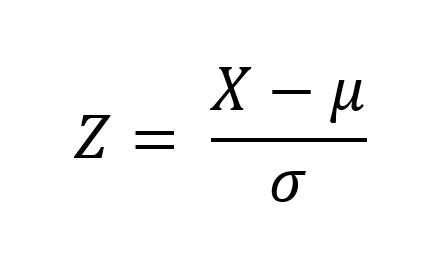

**Import `zscore` Function**
   - `zscore` is imported from the `scipy.stats` module to standardize the data by calculating the z-score for each value.

**Specify Bands for Z-Score Calculation**
   - The `bands` list includes the names of the columns (bands and indices) for which the z-scores will be computed:
     - `['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']`

**Calculate Z-Scores**
   - The `.apply(zscore)` method applies the `zscore` function to each column in the `bands` list within the `Bands` DataFrame.
   - This standardizes each column so that:
     - Mean = 0
     - Standard Deviation = 1
   - The resulting z-scores are stored in the `z_scores` DataFrame.

**Display the Z-Scores**
   - The `z_scores` DataFrame contains the standardized values for each column in the `bands` list. It is displayed to visualize the computed z-scores.

**Plot the Z-Scores**
   - The `.plot()` method is used to create a line plot of the z-scores for all columns in the `bands` list.
   - Each line represents the z-scores of a specific band or index, allowing for a visual comparison of the standardization across the dataset.

**Output**
   - **Z-Scores Table**: A DataFrame showing the z-scores for each value in the specified bands and indices.
   - **Plot**: A line chart illustrating the trends and variations of z-scores across all bands and indices, making it easier to identify patterns or anomalies.
```

In [ ]:
from scipy.stats import zscore

# Calculate z-score for each band
bands = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI",
]
z_scores = Bands[bands].apply(zscore)

# Display the z-scores
z_scores

# Plot the z-scores
z_scores.plot()

z_scores

# Detect outliers (Z-score > 3 or Z-score < -3)
outliers = numeric[(z_scores > 3) | (z_scores < -3)].dropna(how="all")

if outliers.empty:
    print("No outliers detected.")
else:
    print("Outliers detected.")

outliers.count()

***Removing the outliers***

Removing all the Outliers from the dataset

In [ ]:
New_No_Outliers = Bands.drop(outliers.index)
New_No_Outliers

## **Checking for correlation in the data**

## Feature Selection Based on Correlation

To determine which features to retain for the classification of Sentinel-2 bands into waterbodies, bareland, and built-up areas, the correlation of each feature with the target variable (`Class_Label`) was analyzed. The following thresholds were used to guide feature selection:

### Correlation Thresholds
- **Strong correlation**: ( -0.5 <|r| > 0.5 \) (high predictive power, retain these features).
- **Moderate correlation**: ( 0.3 to |r| to 0.5 \) (can be considered for retention but may require validation).
- **Weak correlation**: ( |r| < 0.3 ) (low predictive power, consider removing these features).

---

### Analysis of Features
The correlation values for each feature are as follows:

| Feature      | Correlation with `Class_Label` |
|--------------|---------------------------------|
| B1           | 0.396474                       |
| B2           | 0.385987                       |
| B3           | 0.456653                       |
| B4           | 0.485706                       |
| B5           | 0.621036                       |
| B6           | 0.552642                       |
| B7           | 0.556062                       |
| B8           | 0.585656                       |
| B8A          | 0.595818                       |
| B9           | 0.581494                       |
| B11          | 0.781669                       |
| B12          | 0.751400                       |
| NDVI         | 0.616515                       |
| NDWI         | -0.612607                      |
| NDBI         | 0.612607                       |
| Latitude     | 0.012106                       |
| Longitude    | -0.298161                      |

---

### Features to Retain
The following features show strong correlations (\( |r| > 0.5 \)) with the target variable and should be prioritized for classification:
- **B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12**
- **NDVI, NDWI, NDBI**

These features demonstrate significant predictive power and are critical for distinguishing between waterbodies, bareland, and built-up areas.

---

### Features to Remove
The following features have weak correlations (\( |r| < 0.3 \)) and can be removed as they provide little predictive power:
- **Latitude (0.012106)**: Extremely low correlation.
- **Longitude (-0.298161)**: Weak correlation, likely not useful unless geographic information is critical to the analysis.

In [ ]:
import seaborn as sns
from scipy.stats import spearmanr

# Calculate the Spearman correlation matrix
corr, _ = spearmanr(Bands.drop(columns=["Class_Label", "geometry"]))

# Convert the correlation matrix to a DataFrame for better visualization
corr_df = pd.DataFrame(
    corr,
    index=Bands.drop(columns=["Class_Label", "geometry"]).columns,
    columns=Bands.drop(columns=["Class_Label", "geometry"]).columns,
)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Matrix")
plt.show()

The code calculates the **Spearman correlation matrix** for the features in the **Bands** DataFrame (excluding the **'Class_Label'** and **'geometry'** columns). It then converts the correlation matrix into a DataFrame for better visualization. A mask is applied to hide the upper triangle of the matrix to avoid redundancy. Finally, a **heatmap** is plotted to visually represent the correlation values between the features, with annotations and a color map for clarity.


In [ ]:
import seaborn as sns
from scipy.stats import spearmanr
import numpy as np  # Import numpy

# Calculate the Spearman correlation matrix
corr, _ = spearmanr(Bands.drop(columns=["Class_Label", "geometry"]))

# Convert the correlation matrix to a DataFrame for better visualization
corr_df = pd.DataFrame(
    corr,
    index=Bands.drop(columns=["Class_Label", "geometry"]).columns,
    columns=Bands.drop(columns=["Class_Label", "geometry"]).columns,
)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # Use np.triu instead of pd.triu

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Matrix")
plt.show()

### Purpose of the Script below

The code removes the **'geometry'** column from the **Bands** DataFrame, converts categorical class labels (e.g., 'waterbody', 'built_up', 'bareland') into numerical values (0, 1, 2), and computes the **Spearman correlation** between each feature and the target variable (**'Class_Label'**). The Spearman correlation is used to assess the rank-based relationship between the features and the target class.


In [ ]:
import pandas as pd
import numpy as np

Bands.drop(columns=["geometry"], inplace=True)

# Define the target variable
class_label = "Class_Label"

# Convert the class labels to numerical values, handling missing values
Bands[class_label] = Bands[class_label].map(
    {"waterbody": 0, "built_up": 1, "bareland": 2}
)

# 'data' is your DataFrame, 'Classes' is your target column
spearman_corr = Bands.corr(method="spearman")[class_label]
print("Spearman Correlation with Target:\n", spearman_corr)

- **Class_Label Creation**: The code checks if the **'Class_Label'** column exists in the **Bands** DataFrame. If not, it creates the column by mapping values from the **'Class'** column to labels ('waterbody', 'built_up', 'bareland').

- **Pairplot Visualization**: A **pairplot** is generated using Seaborn to visualize the relationships between selected features (B1, B2, B3, B4, B5, B6, B7, NDVI, NDWI, NDBI) with color coding based on the **'Class_Label'** column. The diagonal shows **Kernel Density Estimation (KDE)** plots for the distribution of each feature.

This code helps in exploring and visualizing the feature relationships and class distributions in the dataset.
```

In [ ]:
# Ensure 'Class_Label' column is present in the Data dataframe
if "Class_Label" not in Bands.columns:
    class_mapping = {1: "waterbody", 2: "built_up", 3: "bareland"}
    Bands["Class_Label"] = Bands["Class"].map(class_mapping)

# Create the pairplot
sns.pairplot(
    Bands[
        [
            "B1",
            "B2",
            "B3",
            "B4",
            "B5",
            "B6",
            "B7",
            "NDVI",
            "NDWI",
            "NDBI",
            "Class_Label",
        ]
    ],
    hue="Class_Label",
    diag_kind="kde",
)

## **After Outlier and Correlation Operation**

The Latitude and Longitude had low correlation and hence removed.

In [ ]:
Cleaned_Data = New_No_Outliers.drop(columns=["Latitude", "Longitude"])
Cleaned_Data

## **Visualisations after Outlier Removal**

The pairplot below shows visualisation after the outliers have been removed from the data

In [ ]:
# Ensure 'Class_Label' column is present in the Data dataframe
if "Class_Label" not in Cleaned_Data.columns:
    class_mapping = {1: "waterbody", 2: "built_up", 3: "bareland"}
    Cleaned_Data["Class_Label"] = Cleaned_Data["Class"].map(class_mapping)

# Create the pairplot
sns.pairplot(
    Cleaned_Data[
        [
            "B1",
            "B2",
            "B3",
            "B4",
            "B5",
            "B6",
            "B7",
            "NDVI",
            "NDWI",
            "NDBI",
            "Class_Label",
        ]
    ],
    hue="Class_Label",
    diag_kind="kde",
)

In [ ]:
from scipy.stats import zscore

# Calculate z-score for each band
bands = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI",
]
z_scores = Cleaned_Data[bands].apply(zscore)

# Display the z-scores
z_scores

# Plot the z-scores
z_scores.plot()

z_scores

### Histograms of Spectral Bands and Indices by Class

### Key Steps:
1. **Define the Color Palette**:
   - Created a palette for `Class_Label` categories:
     - `waterbody`: Blue
     - `built_up`: Red
     - `bareland`: Green.

2. **Subplots Configuration**:
   - Created a grid of subplots (6 rows × 3 columns) for 15 features (`B1`, `B2`, ..., `B12`, `NDVI`, `NDWI`, `NDBI`).
   - Set an overall title using `fig.suptitle`.

3. **Plotting Histograms**:
   - Used `sns.histplot` to plot stacked histograms for each feature, grouped by `Class_Label`.
   - Ensured clear distinction using the color palette and `multiple='stack'`.

4. **Unused Subplots**:
   - Removed any excess subplots if the grid size exceeded the number of features.

5. **Final Adjustments**:
   - Utilized `plt.tight_layout` to optimize spacing.
   - Kept the overall title well-positioned using `rect` adjustments.

### Outcome:
Presented histograms showing the distribution of spectral bands and indices for different land cover classes (`waterbody`, `built_up`, `bareland`). This enables visual analysis of how features vary across classes.


In [ ]:
# Select only numeric columns
numeric = Cleaned_Data.drop(columns=["Class_Label", "geometry", "Class"])
numeric_columns = numeric.select_dtypes(include=[np.number]).columns

for i in numeric_columns:
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(data=Cleaned_Data, x=i, kde=True, bins=20, ax=ax[0])
    sns.violinplot(data=Cleaned_Data, x=i, ax=ax[1])
    sns.boxplot(data=Cleaned_Data, y=i, ax=ax[2], showfliers=False)
    plt.suptitle(f"Visualizing {i}", size=20)

### Histograms of Spectral Bands and Indices by Class

### Key Steps:
1. **Define the Color Palette**:
   - Created a palette for `Class_Label` categories:
     - `waterbody`: Blue
     - `built_up`: Red
     - `bareland`: Green.

2. **Subplots Configuration**:
   - Created a grid of subplots (6 rows × 3 columns) for 15 features (`B1`, `B2`, ..., `B12`, `NDVI`, `NDWI`, `NDBI`).
   - Set an overall title using `fig.suptitle`.

3. **Plotting Histograms**:
   - Used `sns.histplot` to plot stacked histograms for each feature, grouped by `Class_Label`.
   - Ensured clear distinction using the color palette and `multiple='stack'`.

4. **Unused Subplots**:
   - Removed any excess subplots if the grid size exceeded the number of features.

5. **Final Adjustments**:
   - Utilized `plt.tight_layout` to optimize spacing.
   - Kept the overall title well-positioned using `rect` adjustments.

### Outcome:
Presented histograms showing the distribution of spectral bands and indices for different land cover classes (`waterbody`, `built_up`, `bareland`). This enables visual analysis of how features vary across classes.


In [ ]:
# Define the palette
palette = {"waterbody": "blue", "built_up": "red", "bareland": "green"}

# Create subplots
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(20, 30))
fig.suptitle("Histograms of the Bands and Indices by Class_Label", fontsize=16)

# Flatten the axes array for easy iteration
ax = ax.flatten()

# List of columns to plot
columns_to_plot = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI",
]

# Plot each column
for i, column in enumerate(columns_to_plot):
    sns.histplot(
        data=Cleaned_Data,
        x=column,
        hue="Class_Label",
        multiple="stack",
        palette=palette,
        ax=ax[i],
    )
    ax[i].set_title(column)

# Remove any unused subplots
for j in range(len(columns_to_plot), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Boxplots of Spectral Bands and Indices by Class

### Key Steps:
1. **Define the Color Palette**:
   - Created a custom color palette for `Class_Label` categories:
     - `waterbody`: Blue
     - `built_up`: Red
     - `bareland`: Green

2. **Subplots Configuration**:
   - Generated a grid of subplots (4 rows × 5 columns) to accommodate all 15 features (`B1`, `B2`, ..., `B12`, `NDVI`, `NDWI`, `NDBI`).
   - Used `fig.suptitle` to add a title for the entire figure.

3. **Plotting**:
   - Plotted boxplots for each feature grouped by `Class_Label`.
   - Disabled outlier display (`showfliers=False`) for clarity.

4. **Unused Subplots**:
   - Removed empty subplots (if any) to avoid clutter.

5. **Final Layout**:
   - Adjusted the layout with `plt.tight_layout` to prevent overlap of elements.
   - Maintained the overall title position using `rect` adjustment.

### Outcome:
Displayed comparative boxplots for spectral bands and indices across different land cover classes (`waterbody`, `built_up`, `bareland`), providing insights into feature distributions.
```

In [ ]:
# Define the palette
palette = {"waterbody": "blue", "built_up": "red", "bareland": "green"}

# Create subplots
fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(24, 30))
fig.suptitle("Boxplots of the Bands and Indices by Class_Label", fontsize=16)

# Flatten the axes array for easy iteration
ax = ax.flatten()

# List of columns to plot
columns_to_plot = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "NDVI",
    "NDWI",
    "NDBI",
]

# Plot each column
for i, column in enumerate(columns_to_plot):
    sns.boxplot(
        x="Class_Label",
        y=column,
        data=Cleaned_Data,
        ax=ax[i],
        palette=palette,
        showfliers=False,
    )
    ax[i].set_title(column)

# Remove any unused subplots
for j in range(len(columns_to_plot), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **Feature Engineering and Dimension Reduction**

### ***Scaling of the Cleaned Data***

### Feature Standardization

### Key Steps:
1. **Data Preparation**:
   - Extracted the feature matrix `X` by removing non-numeric columns such as `'Class_Label'` and `'geometry'`.
   - Assigned the target variable `Y` to the `'Class_Label'` column.

2. **Standardization**:
   - Applied `StandardScaler` to standardize the features in `X` (mean = 0, variance = 1).
   - Transformed `X` to a standardized format for use in machine learning models.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Exclude geometry column before scaling
X = Cleaned_Data.drop(
    columns=["Class_Label", "geometry"]
)  # Assuming 'geometry' is the column with Point objects
Y = Cleaned_Data["Class_Label"]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

## **Dimension Reduction**

### PCA Dimensionality Reduction and Visualization

### Key Steps:
1. **Perform PCA**:
   - Applied PCA with 3 components to reduce the dimensionality of `X`.
   - Transformed data stored in `principal_components`.

2. **Data Preparation**:
   - Created a DataFrame `pca_df` to store the first three principal components and their corresponding class labels.

3. **Visualization**:
   - Visualized the first two principal components (`PC1` and `PC2`) using a scatter plot.
   - Data points are color-coded based on class labels: *waterbody* (blue), *built-up* (green), and *bareland* (red).
   - Added gridlines, axis labels, and a legend for clarity.

4. **Explained Variance**:
   - Calculated and printed the cumulative variance explained by the PCA components, justifying the dimensionality reduction.

The plot shows how well the first two components separate the class labels while retaining most of the dataset's variance.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Perform PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2", "PC3"])
pca_df["Class_Label"] = Y.values


# Plot the PCA result
fig, ax = plt.subplots(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel("Principal Component 1", fontsize=15)
ax.set_ylabel("Principal Component 2", fontsize=15)
ax.set_title("2 Component PCA", fontsize=20)
targets = ["waterbody", "built_up", "bareland"]
colors = ["b", "g", "r"]
for target, color in zip(targets, colors):
    indices_to_keep = pca_df["Class_Label"] == target
    ax.scatter(
        pca_df.loc[indices_to_keep, "PC1"],
        pca_df.loc[indices_to_keep, "PC2"],
        c=color,
        s=50,
    )
ax.legend(targets)
ax.grid()

# Print statement justifying reducing from 4D to 2D with variance ratio
print(
    "The cumulative explained variance is",
    sum(pca.explained_variance_ratio_) * 100,
    "% ",
)

***Calculating the percentage of explained variance***

### Displaying Variance Explained by PCA Components

This script calculates and displays the percentage of variance explained by each Principal Component (PC) in a PCA analysis:

1. **Variance Calculation**: Multiplies the `explained_variance_ratio_` from the PCA object by 100 to get percentages.
2. **Display**: Iterates through each component, printing the percentage of variance explained.

Each PC's contribution to the dataset's variability is expressed as a percentage, aiding in understanding data dimensionality.


In [ ]:
# Calculate the percentage of variance explained by each component
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Display the percentage of variance explained by each component
for i, variance in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {variance:.2f}%")

## **Unsupervised Classification**

## Finding the Optimal k for K-Means Clustering


This script determines the optimal number of clusters for K-Means using the **Within-Cluster Sum of Squares (WCSS)**, which is visualized with the elbow method.

The Elbow method is used to find the elbow in the elbow chart. The elbow is found when the dataset becomes flat or linear after applying the cluster analysis algorithm. The elbow plot shows the elbow at the point where the number of clusters starts to increase.

The concept of the Elbow method comes from the structure of the arm. However, depending on the value of the ‘metric’ parameter the structure of the elbow method may change. Initially, the k-means clustering algorithm is applied on the dataset for k number of clusters (e.g. k = 2 to 15) to find groups in unlabeled data.

After that, an average score was calculated according to the ‘metric’ parameter. The default value for the metric parameter is ‘skew’, which calculates the sum of the squared distances from the assigned centroids.

When graphs are plotted for the ‘distortion’ value, it gives an arm structure showing the elbow and denotes the number of clusters.

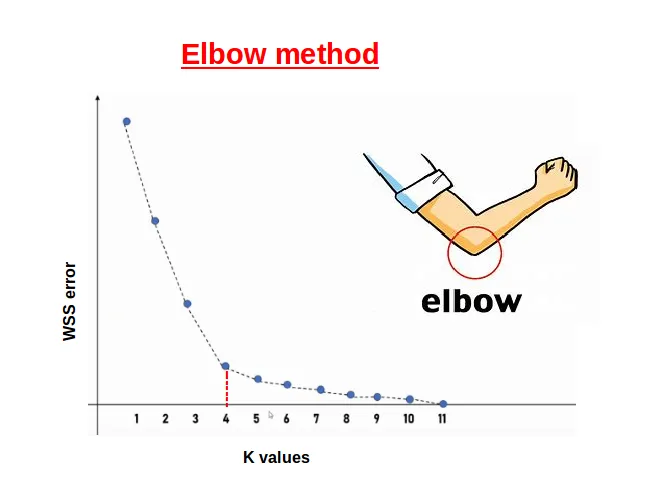



1. **PCA Data**: The script uses PCA-transformed data for clustering.
2. **WCSS Calculation**: It calculates the WCSS for `k` values from 1 to 10.
3. **Plotting**: The WCSS values are plotted against the number of clusters to identify the "elbow," which suggests the optimal number of clusters.

The optimal `k` is identified where the WCSS starts to level off.
```

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use the PCA data
pca_data = principal_components

# Calculate WCSS for different k values
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(pca_data)
    wcss.append(km.inertia_)

# Plot the WCSS to find the optimal k value
plt.plot(range(1, 11), wcss, color="red", marker="8")
plt.title("Optimal K Value")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

## Visualizing Clusters in PCA Space with Centroids

This script visualizes the clusters generated from a clustering model, plotted on a two-dimensional PCA (Principal Component Analysis) space, and highlights the cluster centers.

---

## Steps:
1. **Setting up the plot**:
   - `fig, ax = plt.subplots(figsize=(10, 10))`: Creates a plot with a size of 10x10 inches to ensure clarity for displaying the clusters.

2. **Plotting the clusters**:
   - `scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1], c=y_means, cmap='viridis', s=50)`: This plots the data points (`pca_data`) in the 2D space of the first and second principal components (PCA). The points are colored based on their cluster assignment (`y_means`), and the `viridis` colormap is used for better visibility. The points are marked with a size of 50.
   
3. **Adding a legend for clusters**:
   - `legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")`: Generates a legend for the clusters based on the colors from the `scatter` plot.
   - `ax.add_artist(legend1)`: Adds the legend to the plot.

4. **Indicating the cluster centers**:
   - `centers = model.cluster_centers_`: Retrieves the coordinates of the cluster centers from the model.
   - `ax.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='o', label='Centers')`: Plots the cluster centers on the same PCA plot, using red color and larger markers for distinction.

5. **Finalizing the plot**:
   - `ax.legend()`: Adds a legend to indicate which points are the centers.
   - `ax.set_xlabel('Principal Component 1')`, `ax.set_ylabel('Principal Component 2')`: Labels the axes to indicate the two principal components.
   - `ax.set_title('Clusters Visualization')`: Adds a title to the plot.
   - `ax.grid()`: Adds a grid for better visualization of points and clusters.
   - `plt.style.use('dark_background')`: Sets the plot background to dark for better contrast.
   - `plt.show()`: Displays the plot.

---

## Outcome:
- The resulting plot shows the clusters in PCA space with their corresponding colors, and the red markers indicate the cluster centers. This visualization is useful for understanding the distribution of the data and how the clustering model has grouped the points.


In [ ]:
from sklearn.cluster import KMeans

# Define the number of clusters
num_clusters = 4

# Fit the KMeans model with the specified number of clusters
model = KMeans(n_clusters=num_clusters, random_state=0)
y_means = model.fit_predict(pca_data)

# Plot the clusters
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1], c=y_means, cmap="viridis", s=50)
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

# Indicate the centers
centers = model.cluster_centers_
ax.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    alpha=0.75,
    marker="o",
    label="Centers",
)
ax.legend()

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Clusters Visualization")
ax.grid()
plt.show()

## **Supervised Classification**

## Extracting Geometry from Geospatial Data

This line of code extracts the geometry information from a geospatial dataset (likely a GeoDataFrame) for further analysis.

---

## Steps:
1. **Extracting Geometry**:
   - `geometry = Cleaned_Data['geometry']`: This accesses the 'geometry' column from the `Cleaned_Data` dataset (assumed to be a GeoDataFrame). The `geometry` column typically contains geometric shapes or points, such as coordinates (latitude, longitude) or other spatial features, which represent locations or regions on the Earth's surface.

---

## Outcome:
- The variable `geometry` now holds the geometrical data from `Cleaned_Data['geometry']`. This can include points, lines, or polygons, and is often used in geospatial analysis for tasks like mapping, spatial queries, or extracting pixel values from satellite imagery.
```

In [ ]:
geometry = Cleaned_Data["geometry"]
geometry

## Creating a DataFrame with Geospatial Data

This script creates a DataFrame from the extracted pixel values and associates each row with its corresponding geometry.

---

## Steps:
1. **Creating the DataFrame**:
   - `current_data = pd.DataFrame(X)`: A Pandas DataFrame is created using the array `X`, which contains the extracted pixel values from the Sentinel-2 bands. Each row represents a point with its corresponding band values.

2. **Adding Geometry**:
   - `current_data['geometry'] = geometry`: The `geometry` column (containing the geographical coordinates or shapes) is added to the DataFrame `current_data`. This column allows for linking the pixel values in `X` to their corresponding locations in geographic space.

3. **Displaying the DataFrame**:
   - `current_data`: Displays the final DataFrame, which now contains both the extracted pixel values from Sentinel-2 imagery as well as the corresponding geographical coordinates or shapes.

---

## Outcome:
- `current_data` is a Pandas DataFrame that combines the pixel values (`X`) with the geometry (`geometry`) information. This DataFrame can be used for further analysis or visualization, including spatial data processing and machine learning.
```

In [ ]:
# Assuming 'geometry' is your GeoSeries
current_data = pd.DataFrame(X)  # Create the DataFrame with data from X
current_data["geometry"] = geometry  # Add the geometry as a new column
current_data

## Extracting Band Values for Geospatial Data

This script extracts pixel values from Sentinel-2 imagery for a set of points in a geospatial dataset and stores them in a 2D array.

---

## Steps:
1. **Array Initialization**:
   - `array_samples = []`: An empty list is created to store the extracted pixel values for each point.

2. **Looping through Geometry Points**:
   - `for point in Cleaned_Data['geometry']`: Iterates through each geometry point (likely latitude and longitude) in the `Cleaned_Data` dataset.

3. **Get Row and Column Indices**:
   - `x = point.xy[0][0]`: Extracts the x-coordinate (longitude) of the point.
   - `y = point.xy[1][0]`: Extracts the y-coordinate (latitude) of the point.
   - `row, col = sentinel2.index(x, y)`: Uses the `sentinel2` object to convert the geographic coordinates into row and column indices corresponding to the image grid.

4. **Extracting Band Values**:
   - `band_value = []`: Initializes an empty list to store the pixel values for all bands at the specific point.
   - `for i in range(sentinel2.count)`: Loops through all bands of the Sentinel-2 image.
   - `band_value.append(sentinel2.read(i+1)[row, col - 1 if col == sentinel2.width else col])`: For each band, it reads the value at the computed row and column indices and appends it to the `band_value` list. The code ensures the column is within the valid range by adjusting it if necessary.

5. **Store Extracted Values**:
   - `array_samples.append(band_value)`: Adds the list of pixel values for the current point to the `array_samples` list.

6. **Convert to Numpy Array**:
   - `X = np.array(array_samples)`: Converts the list of band values into a NumPy array `X` for further analysis.

---

## Outcome:
- `X` is a 2D NumPy array where each row corresponds to a set of pixel values for a point in the dataset, with each column representing a different band from the Sentinel-2 imagery.
```

In [ ]:
array_samples = []
for point in Cleaned_Data["geometry"]:
    x = point.xy[0][0]
    y = point.xy[1][0]
    row, col = sentinel2.index(
        x, y
    )  # Use the 'sentinel2' object to get row and col indices
    band_value = []
    for i in range(sentinel2.count):
        # Subtract 1 from col to ensure it's within the valid range (0-372)
        band_value.append(
            sentinel2.read(i + 1)[row, col - 1 if col == sentinel2.width else col]
        )
    array_samples.append(band_value)

X = np.array(array_samples)
X.shape

## Importing Metrics and Preprocessing Utilities

This script imports necessary modules for evaluating model performance and encoding categorical labels.

---

## Imports:
1. **Confusion Matrix**:
   - `confusion_matrix`: A function from `sklearn.metrics` used to compute the confusion matrix. It compares the true labels (`y_test`) with the predicted labels (`y_pred`) to evaluate the classification model's performance.

2. **Label Encoding**:
   - `LabelEncoder`: A utility from `sklearn.preprocessing` that transforms categorical labels into numeric labels. This is useful for preparing target variables that are in string format, as many machine learning algorithms require numeric data.

---

## Outcome:
- The script is set up with the necessary tools for classification performance evaluation and label transformation to numerical format.
```

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

## Label Encoding for Target Variable

This script applies label encoding to the target variable `Y` to convert categorical labels into numerical format.

---

## Steps:
1. **LabelEncoder Initialization**:
   - `LabelEncoder`: A utility from `sklearn` that transforms categorical labels into numeric values.

2. **Label Encoding**:
   - `Y = labelencoder.fit_transform(Y)`: The `fit_transform()` method is applied to the target variable `Y` to encode each unique label into an integer.
   
   - The `fit()` method learns the mapping of unique labels to integers, and the `transform()` method applies this mapping to the data.
   
3. **Output**:
   - `Y`: The target variable is now encoded as a numeric array, where each label is replaced by an integer value.

---

## Outcome:
- The categorical labels in `Y` are transformed into numeric values, making them compatible with machine learning algorithms that require numerical input.


In [ ]:
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(Y)
Y

## Model Setup and Train-Test Split

This script sets up different machine learning models and splits the dataset into training and testing subsets.

---

## Steps:
1. **Model Imports**:
   - `SVC`: Support Vector Classifier (SVM) for classification.
   - `RandomForestClassifier`: Random Forest Classifier for classification.
   - `MLPClassifier`: Multi-layer Perceptron (MLP) classifier for neural network-based classification.
   
2. **Cross-Validation and Evaluation**:
   - `cross_val_score`: Used for evaluating model performance through cross-validation.
   - `StratifiedKFold`: Ensures that each fold has the same distribution of class labels.
   
3. **Train-Test Split**:
   - `train_test_split`: Splits the data (`X` and `Y`) into training and testing sets.
   - `test_size=0.25`: 25% of the data is used for testing, and the remaining 75% is used for training.
   - `random_state=0`: Ensures reproducibility by setting a fixed random seed for splitting.

---

## Outcome:
- The dataset is split into `X_train`, `X_test`, `y_train`, and `y_test` for training and evaluation, with the specified test size.
- Models are ready for cross-validation and training.
```

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

## **Multi-Layer Perceptron Neural Network**

### **Model Training**

***Multi Layer Preceptron Neural Network***

## MLP Model Configuration for Classification

This script sets the configuration parameters for the Multi-Layer Perceptron (MLP) classifier, which will be used for training and classification tasks.

---

## Configuration Details:
1. **Model Architecture**:
   - `hidden_layer_sizes=(400,)`: The model has one hidden layer with 400 neurons.
   - `activation='relu'`: ReLU (Rectified Linear Unit) is used as the activation function for the hidden layer.
   
2. **Optimizer and Regularization**:
   - `solver='adam'`: The Adam optimizer is used for weight optimization.
   - `alpha=0.0001`: L2 regularization term to prevent overfitting.
   
3. **Batch and Learning Rate**:
   - `batch_size='auto'`: Automatically determines the batch size based on the dataset size.
   - `learning_rate='constant'`: The learning rate remains constant during training.
   - `learning_rate_init=0.001`: The initial learning rate set to 0.001.
   - `power_t=0.5`: Exponent for inverse scaling of the learning rate.
   
4. **Training Settings**:
   - `max_iter=500`: The model will train for a maximum of 500 iterations (epochs).
   - `shuffle=True`: Data will be shuffled at each epoch to ensure better generalization.
   - `tol=1e-4`: Tolerance for optimization convergence (early stopping criterion).
   - `verbose=False`: No verbose output during training.
   - `warm_start=False`: The model does not reuse previous solutions for warm restarts.
   
5. **Momentum and Convergence**:
   - `momentum=0.9`: Momentum for the gradient descent optimization.
   - `nesterovs_momentum=True`: Uses Nesterov's momentum for better convergence behavior.
   - `n_iter_no_change=10`: If the model doesn't improve for 10 iterations, the training stops.
   
6. **Adam Optimizer Parameters**:
   - `beta_1=0.9`: The exponential decay rate for the first moment estimate in Adam.
   - `beta_2=0.999`: The exponential decay rate for the second moment estimate in Adam.
   - `epsilon=1e-8`: A small constant for numerical stability in the Adam optimizer.

7. **Additional Settings**:
   - `max_fun=15000`: Maximum number of function evaluations allowed during optimization.

---

## Outcome:
- The MLP classifier is set up with specific hyperparameters that balance model complexity, convergence, and performance for the classification task.


In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(400,),  # One hidden layer with 100 neurons
    activation="relu",  # Activation function is ReLU
    solver="adam",  # Optimizer is Adam
    alpha=0.0001,  # L2 regularization term
    batch_size="auto",  # Batch size automatically set based on sample size
    learning_rate="constant",  # Constant learning rate
    learning_rate_init=0.001,  # Initial learning rate
    power_t=0.5,  # Exponent for inverse scaling of learning rate
    max_iter=500,  # Maximum number of iterations (epochs)
    shuffle=True,  # Shuffle data at each epoch
    random_state=None,  # No fixed random seed
    tol=1e-4,  # Tolerance for optimization convergence
    verbose=False,  # No output during training
    warm_start=False,  # Do not reuse previous solution for warm restarts
    momentum=0.9,  # Momentum for gradient descent
    nesterovs_momentum=True,  # Use Nesterov's momentum
    early_stopping=False,  # Do not use early stopping
    validation_fraction=0.1,  # Fraction of data to set aside for validation (used if early_stopping=True)
    beta_1=0.9,  # Beta1 for Adam optimizer
    beta_2=0.999,  # Beta2 for Adam optimizer
    epsilon=1e-8,  # Epsilon for numerical stability in Adam
    n_iter_no_change=10,  # Iterations without improvement to trigger convergence
    max_fun=15000,  # Maximum function evaluations
)

***Performing Cross Validation***

## MLP Model Training Accuracy with Cross-Validation

This script evaluates the training accuracy of the Multi-Layer Perceptron (MLP) model using cross-validation.

---

## Steps:
1. **Cross-Validation Setup**:
   - A 10-fold Stratified Cross-Validation (`StratifiedKFold`) is used to ensure each fold has a balanced class distribution.
   - The model will be trained and evaluated on the training data (`X_train`, `y_train`) using `cross_val_score()`.

2. **Model Evaluation**:
   - The accuracy for each fold is calculated, and the mean accuracy is computed and displayed as the overall training accuracy.

---

## Outcome:
- Prints the average training accuracy of the MLP model over 10 cross-validation folds, providing a more robust estimate of model performance.
```

In [ ]:
kfold = StratifiedKFold(n_splits=10, random_state=None)
cv_results = cross_val_score(mlp_model, X_train, y_train, cv=kfold, scoring="accuracy")
print("The training accuracy of MLP: %f" % cv_results.mean())

***Model Testing***

## Training and Evaluating MLP Model Accuracy

This script trains the Multi-Layer Perceptron (MLP) model and evaluates its performance by predicting test labels and calculating accuracy.

---

## Steps:
1. **Model Training**:
   - The MLP model is trained using the training dataset (`X_train`, `y_train`) via the `fit()` method.

2. **Prediction**:
   - Predictions are made for the test dataset (`X_test`) using the trained MLP model.

3. **Accuracy Calculation**:
   - The accuracy of the model on the test set is calculated using `accuracy_score()` and displayed as a percentage.

4. **Concatenated Output**:
   - The predicted labels (`MLP_y_pred`) and the actual labels (`y_test`) are concatenated and printed side-by-side for easy comparison.

---

## Outcome:
- Displays the testing accuracy of the MLP model on the test set.
- Prints a side-by-side comparison of predicted and actual test labels, enabling an assessment of model performance.
```

In [ ]:
# Fit the model
mlp_model.fit(X_train, y_train)

# Predict the labels for the test set
MLP_y_pred = mlp_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Calculate the accuracy
test_accuracy = accuracy_score(y_test, MLP_y_pred) * 100
print(f"Testing Accuracy: {test_accuracy:.4f}%")

# Print the concatenated predictions and actual values
print(
    np.concatenate(
        (MLP_y_pred.reshape(len(MLP_y_pred), 1), y_test.reshape(len(y_test), 1)), 1
    )
)

## Confusion Matrix and Classification Report for MLP Model

This script evaluates the performance of the Multi-Layer Perceptron (MLP) model using a confusion matrix and a classification report.

---

## Steps:
1. **Confusion Matrix**:
   - The confusion matrix is calculated using `confusion_matrix()` to compare the true labels (`y_test`) with the predicted labels (`MLP_y_pred`).
   
2. **Visualization**:
   - The confusion matrix is visualized using a heatmap created with `seaborn.heatmap()`. Annotations are added to display the counts, and the axis labels (`Predicted` and `Actual`) are included for clarity.

3. **Classification Report**:
   - The `classification_report()` is used to generate detailed metrics, including precision, recall, F1-score, and support for each class in the classification task.

---

## Outcome:
- A heatmap of the confusion matrix showing the true vs. predicted class distribution.
- A printed classification report that summarizes the model's performance for each class, providing key evaluation metrics.
```

In [ ]:
from sklearn.metrics import classification_report

# Generate the confusion matrix for the SVM
cm = confusion_matrix(y_test, MLP_y_pred)

# Optionally, you can visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for MLP")
plt.show()

# You can also generate a classification report for more detailed metrics
print(classification_report(y_test, MLP_y_pred))

## **Applying the model to the Image**

## Handling NaN Values in Sentinel Image for Prediction

This script processes a Sentinel image by replacing NaN values and checking its shape.

---

## Steps:
1. **Handling NaN Values**:
   - The `np.nan_to_num()` function is used to replace any NaN (Not a Number) values in the `sentinel_image` with zero or a specified value (by default, NaN values are replaced with `0`).

2. **Check Shape**:
   - The shape of the processed `predict_img` is retrieved using `.shape`, which provides the dimensions (height, width, and possibly the number of bands) of the image.

---

## Outcome:
- The `predict_img` array is cleaned of any NaN values, and its shape (dimensions) is displayed, ensuring that the image is ready for further processing or prediction.


In [ ]:
predict_img = np.nan_to_num(sentinel_image)
predict_img.shape

## MLP Model Prediction and Visualization for LULC Classification

This script uses a Multi-Layer Perceptron (MLP) model to predict Land Use/Land Cover (LULC) classes and visualize the results with a custom colormap.

---

## Steps:
1. **Reshaping the Image**:
   - The `predict_img` is reshaped into a 2D array (`predict_img_reshaped`) with one row for each pixel and columns representing the pixel's features (e.g., spectral bands).

2. **Prediction**:
   - The reshaped image is passed to the trained MLP model (`mlp_model.predict()`) to predict the LULC class labels for each pixel.

3. **Reshaping Back**:
   - The predicted labels (`Mlp_classified`) are reshaped back into the original 2D shape of the `sentinel_image`.

4. **Custom Colormap**:
   - A custom colormap (`ListedColormap`) is defined to represent different LULC classes with specific colors:
     - `green`: Represents one class (e.g., vegetation).
     - `yellow`: Represents another class (e.g., urban areas).
     - `blue`: Represents a third class (e.g., water).

5. **Visualization**:
   - The classified image is displayed using `plt.imshow()` with the custom colormap.
   - The plot is titled `MLP Classified LULC Image`, and axis labels are hidden for clarity.

---

## Outcome:
- A visual representation of the LULC classification with colors representing different land cover types, generated by the MLP model.
```

In [ ]:
# Reshape the predict_img to a 2D array
predict_img_reshaped = predict_img.reshape(-1, predict_img.shape[2])

# Predict using the reshaped image
Mlp_classified = mlp_model.predict(predict_img_reshaped)

Mlp_classified = Mlp_classified.reshape(
    sentinel_image.shape[0], sentinel_image.shape[1]
)

# Define the custom colormap
cmap = ListedColormap(["green", "yellow", "blue"])

# Plot the predicted image with the custom colormap
plt.figure(figsize=[20, 20])
plt.imshow(Mlp_classified, cmap=cmap)
plt.title("MLP CLassified LULC Image", fontsize=40)
plt.axis("off")
plt.show()

### **Applying hexgonal grid**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon


def plot_hexagonal_grid(classified_image, density_data, cmap="viridis"):

    height, width = classified_image.shape
    hex_size = 7  # Adjust size of hexagons as needed

    fig, ax = plt.subplots(figsize=(10, 10))

    # Display classified image
    ax.imshow(
        classified_image, cmap=plt.get_cmap("gray")
    )  # Replace 'gray' with actual colormap

    # Create Hexagonal Grid
    for y in range(0, height, hex_size):
        for x in range(0, width, hex_size):
            # Calculate density
            density_value = np.mean(density_data[y : y + hex_size, x : x + hex_size])
            # Create a hexagon
            hexagon = RegularPolygon(
                (x + hex_size // 2, y + hex_size // 2),
                numVertices=6,
                radius=hex_size // 2,
                orientation=np.radians(30),  # Rotate by 30 degrees
                facecolor=plt.cm.get_cmap(cmap)(
                    density_value
                ),  # Color based on density
                alpha=0.7,
                edgecolor="black",  # Add a black edge to enhance visibility
            )
            ax.add_patch(hexagon)

    # Create a colorbar as a legend
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=np.min(density_data), vmax=np.max(density_data)),
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label("Density")

    plt.title("Classified Image with Hexagonal Density Overlay")
    plt.axis("off")
    plt.show()


# density calculation based on class labels (you might have a better method):
def calculate_density(classified_image):
    density_map = np.zeros_like(classified_image, dtype=float)
    for class_label in np.unique(classified_image):
        class_locations = np.where(classified_image == class_label)
        density_map[class_locations] = np.sum(classified_image == class_label)
    return density_map / np.max(density_map)  # Normalize


density_map = calculate_density(Mlp_classified)
plot_hexagonal_grid(Mlp_classified, density_map)

## **Support Vector Machine**

### **Model Training**

## Support Vector Machine (SVM) Model Training Accuracy with Cross-Validation

This script initializes a Support Vector Machine (SVM) model and evaluates its training accuracy using cross-validation.

---

## Steps:
1. **Model Initialization**:
   - An SVM classifier (`Svm_model`) is created with the following parameters:
     - `kernel='rbf'`: Radial Basis Function (RBF) kernel for nonlinear classification.
     - `C=7.0`: Regularization parameter to control the trade-off between achieving a low error on the training set and minimizing model complexity.
     - `gamma='auto'`: Kernel coefficient for the RBF kernel.
     - `shrinking=True`: Uses shrinking heuristics to speed up computations.
     - Other parameters include `tol=0.0001`, `cache_size=200 MB`, and `decision_function_shape='ovr'` (One-vs-Rest for multi-class classification).

2. **Cross-Validation**:
   - A 10-fold Stratified Cross-Validation (`StratifiedKFold`) is applied to maintain balanced class distribution in each fold.
   - The model's accuracy is evaluated on the training data (`X_train`, `y_train`) using `cross_val_score()`.

3. **Accuracy Calculation**:
   - The mean accuracy from all 10 folds is computed and displayed as the training accuracy.

---

## Outcome:
- Prints the training accuracy of the SVM model averaged over 10 cross-validation folds.


In [ ]:
Svm_model = SVC(
    kernel="rbf",
    random_state=0,
    C=7.0,
    gamma="auto",
    shrinking=True,
    probability=False,
    tol=0.0001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape="ovr",
)

kfold = StratifiedKFold(n_splits=10, random_state=None)
cv_results = cross_val_score(Svm_model, X_train, y_train, cv=kfold, scoring="accuracy")
print("The training accuracy of SVM: %f" % cv_results.mean())

## **Model Testing**

## Confusion Matrix and Classification Report for SVM Model

This script evaluates the performance of a SVM model using a confusion matrix and a classification report.

---

### Steps:
1. **Confusion Matrix**:
   - The confusion matrix is calculated using `confusion_matrix()` to compare the true labels (`y_test`) with predicted labels (`RF_y_pred`).
   - Unique class labels are extracted from `y_test` to ensure accurate representation.

2. **Visualization**:
   - The confusion matrix is displayed using `ConfusionMatrixDisplay()` for easy interpretation of model performance across all classes.

3. **Classification Report**:
   - `classification_report()` provides detailed metrics, including precision, recall, F1-score, and support for each class.

---

## Outcome:
- A visual confusion matrix plot showing the accuracy of predictions for each class.
- A printed classification report summarizing the model's performance metrics for all classes.
```

In [ ]:
# Fit the model
Svm_model.fit(X_train, y_train)

# Predict the labels for the test set
SVM_y_pred = Svm_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Calculate the accuracy
test_accuracy = accuracy_score(y_test, SVM_y_pred) * 100
print(f"Testing Accuracy: {test_accuracy:.4f}%")

# Print the concatenated predictions and actual values
print(
    np.concatenate(
        (SVM_y_pred.reshape(len(SVM_y_pred), 1), y_test.reshape(len(y_test), 1)), 1
    )
)

In [ ]:
# Generate the confusion matrix for the SVM
cm = confusion_matrix(y_test, SVM_y_pred)

# Optionally, you can visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()

# You can also generate a classification report for more detailed metrics
print(classification_report(y_test, SVM_y_pred))

# SVM Classified LULC Image Visualization

This script predicts and visualizes Land Use/Land Cover (LULC) classes using a pre-trained SVM model and a custom colormap.

---

## Steps:
1. **Prediction**:
   - The RF model predicts LULC class labels for each pixel of the reshaped Sentinel image.
   - Predictions are reshaped back to the image's original 2D dimensions.

2. **Custom Colormap**:
   - A `ListedColormap` assigns specific colors (e.g., green, yellow, blue) to each LULC class for better interpretability.

3. **Visualization**:
   - The classified image is displayed using `plt.imshow()` with the custom colormap.
   - A title is added, and axes are hidden for clarity.

---

## Outcome:
- A clear, color-coded map of LULC classes for the Sentinel image, enabling easy interpretation of land cover patterns.


In [ ]:
# Predict using the reshaped image
svm_classified = Svm_model.predict(predict_img_reshaped)
svm_classified = svm_classified.reshape(
    sentinel_image.shape[0], sentinel_image.shape[1]
)

# Define the custom colormap
cmap = ListedColormap(["green", "yellow", "blue"])

# Plot the predicted image with the custom colormap
plt.figure(figsize=[20, 20])
plt.imshow(svm_classified, cmap=cmap)
plt.title("SVM CLassified LULC Image", fontsize=40)
plt.axis("off")
plt.show()

### Hexagonal Density Overlay on SVM Classified Image

This script generates a **visual representation** of a classified image overlaid with a **hexagonal grid**, where the hexagons are colored based on computed **density values**. Below is the explanation of its components:

---

## 1. Purpose
- **Display a classified image.**
- **Overlay a hexagonal grid** on the image.
- **Color hexagons based on density** of class labels in the grid cells.

---

## 2. Key Functions

### 2.1 `calculate_density(classified_image)`
- **Input**:
  - A classified image where each pixel has a class label.
- **Process**:
  1. Identifies all unique class labels in the image.
  2. For each label, calculates the density of that class across the image.
  3. Normalizes the density values to a range of [0, 1].
- **Output**:
  - A density map representing the relative density of each class label in the image.

---

### 2.2 `plot_hexagonal_grid(classified_image, density_data, cmap='viridis')`
- **Inputs**:
  - `classified_image`: The image to be displayed.
  - `density_data`: The normalized density values.
  - `cmap`: Colormap for visualizing density.
- **Process**:
  1. Displays the classified image as the background.
  2. Iterates through the image with a specified hexagon size (`hex_size`).
  3. For each grid cell:
     - Calculates the average density value from `density_data`.
     - Creates a hexagon centered at the grid cell.
     - Colors the hexagon based on the calculated density using the specified colormap.
  4. Adds the hexagons to the plot.
  5. Displays a color bar to indicate the density values.
- **Output**:
  - A combined visualization of the classified image and a hexagonal density overlay.

---

## 3. How It Works
1. **Calculate Density**:
   - The `calculate_density` function computes a density map for the image.
2. **Plot Hexagonal Grid**:
   - The `plot_hexagonal_grid` function:
     1. Displays the classified image as the base layer.
     2. Divides the image into hexagonal grid cells of a given size.
     3. Colors each hexagon based on the average density of the corresponding grid cell.
     4. Adds a color bar to serve as a legend for the density values.

---

## 4. Visualization Outcome
- A plot with:
  1. The original classified image in grayscale (or another base colormap).
  2. A **hexagonal density overlay** where hexagons are color-coded by density values.
  3. A **color bar legend** indicating the range of density values.
- This allows clear visualization of how class densities are distributed across the image.

---

Would you like assistance in adapting this code for specific data or making further improvements?
```

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon


def plot_hexagonal_grid(classified_image, density_data, cmap="viridis"):

    height, width = classified_image.shape
    hex_size = 7  # Adjust size of hexagons as needed

    fig, ax = plt.subplots(figsize=(10, 10))

    # Display classified image
    ax.imshow(
        classified_image, cmap=plt.get_cmap("gray")
    )  # Replace 'gray' with actual colormap

    # Create Hexagonal Grid
    for y in range(0, height, hex_size):
        for x in range(0, width, hex_size):
            # Calculate density
            density_value = np.mean(density_data[y : y + hex_size, x : x + hex_size])
            # Create a hexagon
            hexagon = RegularPolygon(
                (x + hex_size // 2, y + hex_size // 2),
                numVertices=6,
                radius=hex_size // 2,
                orientation=np.radians(30),  # Rotate by 30 degrees
                facecolor=plt.cm.get_cmap(cmap)(
                    density_value
                ),  # Color based on density
                alpha=0.7,
                edgecolor="black",  # Add a black edge to enhance visibility
            )
            ax.add_patch(hexagon)

    # Create a colorbar as a legend
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=np.min(density_data), vmax=np.max(density_data)),
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label("Density")

    plt.title("Classified Image with Hexagonal Density Overlay")
    plt.axis("off")
    plt.show()


# density calculation based on class labels (you might have a better method):
def calculate_density(classified_image):
    density_map = np.zeros_like(classified_image, dtype=float)
    for class_label in np.unique(classified_image):
        class_locations = np.where(classified_image == class_label)
        density_map[class_locations] = np.sum(classified_image == class_label)
    return density_map / np.max(density_map)  # Normalize


density_map = calculate_density(svm_classified)
plot_hexagonal_grid(svm_classified, density_map)

## **Random Forest**

**Random Forest Model Training**

## Random Forest Model Training Accuracy with Cross-Validation

This script initializes a Random Forest (RF) classifier and evaluates its training accuracy using cross-validation.

---

## Steps:
1. **Model Initialization**:
   - A Random Forest classifier (`RF_model`) is created with the following parameters:
     - `n_estimators=200`: Number of decision trees in the forest.
     - `criterion='gini'`: Splitting criterion based on Gini impurity.
     - `max_depth=None`: No limit on the depth of trees.
     - `min_samples_split=2`: Minimum number of samples required to split a node.
     - `min_samples_leaf=1`: Minimum number of samples required at each leaf node.

2. **Cross-Validation**:
   - A 10-fold Stratified Cross-Validation (`StratifiedKFold`) is applied to ensure balanced class representation in each fold.
   - The model's accuracy is evaluated on the training data (`X_train`, `y_train`) using `cross_val_score()`.

3. **Accuracy Calculation**:
   - The mean accuracy from all 10 folds is computed and displayed as the training accuracy.

---

## Outcome:
- Prints the training accuracy of the Random Forest model averaged over 10 cross-validation folds.
```

In [ ]:
RF_model = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
)

kfold = StratifiedKFold(n_splits=10, random_state=None)
cv_results = cross_val_score(RF_model, X_train, y_train, cv=kfold, scoring="accuracy")
print("The training accuracy of Random Forest: %f" % cv_results.mean())

**Random Forest**

## Training and Evaluating Random Forest Model

This script trains a Random Forest (RF) model and evaluates its performance by predicting test labels and calculating accuracy.

---

## Steps:
1. **Model Training**:
   - The RF model is trained on the training dataset (`X_train`, `y_train`) using the `fit()` method.

2. **Prediction**:
   - Predictions are made on the test dataset (`X_test`) using the trained model.

3. **Accuracy Calculation**:
   - The accuracy of the model on the test set is calculated using `accuracy_score()` and displayed as a percentage.

4. **Concatenated Output**:
   - Predicted labels (`RF_y_pred`) and actual labels (`y_test`) are concatenated and printed side-by-side for easy comparison.

---

## Outcome:
- Displays the testing accuracy of the model.
- Prints a side-by-side comparison of predicted and actual test labels to assess model performance.


In [ ]:
# Fit the model
RF_model.fit(X_train, y_train)

# Predict the labels for the test set
RF_y_pred = RF_model.predict(X_test)

from sklearn.metrics import accuracy_score

# Calculate the accuracy
test_accuracy = accuracy_score(y_test, RF_y_pred) * 100
print(f"Testing Accuracy: {test_accuracy:.4f}%")

# Print the concatenated predictions and actual values
print(
    np.concatenate(
        (RF_y_pred.reshape(len(RF_y_pred), 1), y_test.reshape(len(y_test), 1)), 1
    )
)

## Confusion Matrix and Classification Report for Random Forest Model

This script evaluates the performance of a Random Forest (RF) model using a confusion matrix and a classification report.

---

### Steps:
1. **Confusion Matrix**:
   - The confusion matrix is calculated using `confusion_matrix()` to compare the true labels (`y_test`) with predicted labels (`RF_y_pred`).
   - Unique class labels are extracted from `y_test` to ensure accurate representation.

2. **Visualization**:
   - The confusion matrix is displayed using `ConfusionMatrixDisplay()` for easy interpretation of model performance across all classes.

3. **Classification Report**:
   - `classification_report()` provides detailed metrics, including precision, recall, F1-score, and support for each class.

---

## Outcome:
- A visual confusion matrix plot showing the accuracy of predictions for each class.
- A printed classification report summarizing the model's performance metrics for all classes.
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Generate the confusion matrix
cm = confusion_matrix(y_test, RF_y_pred)

# Instead of RF_model.classes_, extract unique class labels from y_test
# or y_train if y_test doesn't contain all classes.
labels = np.unique(y_test)

# Create a ConfusionMatrixDisplay object with the extracted labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot the confusion matrix
disp.plot()
plt.show()

# Print the classification report
print(classification_report(y_test, RF_y_pred))

# Random Forest Classified LULC Image Visualization

This script predicts and visualizes Land Use/Land Cover (LULC) classes using a pre-trained Random Forest (RF) model and a custom colormap.

---

## Steps:
1. **Prediction**:
   - The RF model predicts LULC class labels for each pixel of the reshaped Sentinel image.
   - Predictions are reshaped back to the image's original 2D dimensions.

2. **Custom Colormap**:
   - A `ListedColormap` assigns specific colors (e.g., green, yellow, blue) to each LULC class for better interpretability.

3. **Visualization**:
   - The classified image is displayed using `plt.imshow()` with the custom colormap.
   - A title is added, and axes are hidden for clarity.

---

## Outcome:
- A clear, color-coded map of LULC classes for the Sentinel image, enabling easy interpretation of land cover patterns.


In [ ]:
# Predict using the reshaped image
RF_classified = RF_model.predict(predict_img_reshaped)
RF_classified = RF_classified.reshape(sentinel_image.shape[0], sentinel_image.shape[1])

# Define the custom colormap
cmap = ListedColormap(["green", "yellow", "blue"])

# Plot the predicted image with the custom colormap
plt.figure(figsize=[20, 20])
plt.imshow(RF_classified, cmap=cmap)
plt.title("Random Forest CLassified LULC Image", fontsize=40)
plt.axis("off")
plt.show()

### **Applying Hexagonal Grids**

### Hexagonal Density Overlay on Classified Image

This script generates a **visual representation** of a classified image overlaid with a **hexagonal grid**, where the hexagons are colored based on computed **density values**. Below is the explanation of its components:

---

## 1. Purpose
- **Display a classified image.**
- **Overlay a hexagonal grid** on the image.
- **Color hexagons based on density** of class labels in the grid cells.

---

## 2. Key Functions

### 2.1 `calculate_density(classified_image)`
- **Input**:
  - A classified image where each pixel has a class label.
- **Process**:
  1. Identifies all unique class labels in the image.
  2. For each label, calculates the density of that class across the image.
  3. Normalizes the density values to a range of [0, 1].
- **Output**:
  - A density map representing the relative density of each class label in the image.

---

### 2.2 `plot_hexagonal_grid(classified_image, density_data, cmap='viridis')`
- **Inputs**:
  - `classified_image`: The image to be displayed.
  - `density_data`: The normalized density values.
  - `cmap`: Colormap for visualizing density.
- **Process**:
  1. Displays the classified image as the background.
  2. Iterates through the image with a specified hexagon size (`hex_size`).
  3. For each grid cell:
     - Calculates the average density value from `density_data`.
     - Creates a hexagon centered at the grid cell.
     - Colors the hexagon based on the calculated density using the specified colormap.
  4. Adds the hexagons to the plot.
  5. Displays a color bar to indicate the density values.
- **Output**:
  - A combined visualization of the classified image and a hexagonal density overlay.

---

## 3. How It Works
1. **Calculate Density**:
   - The `calculate_density` function computes a density map for the image.
2. **Plot Hexagonal Grid**:
   - The `plot_hexagonal_grid` function:
     1. Displays the classified image as the base layer.
     2. Divides the image into hexagonal grid cells of a given size.
     3. Colors each hexagon based on the average density of the corresponding grid cell.
     4. Adds a color bar to serve as a legend for the density values.

---

## 4. Visualization Outcome
- A plot with:
  1. The original classified image in grayscale (or another base colormap).
  2. A **hexagonal density overlay** where hexagons are color-coded by density values.
  3. A **color bar legend** indicating the range of density values.
- This allows clear visualization of how class densities are distributed across the image.

---

Would you like assistance in adapting this code for specific data or making further improvements?
```

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon


def plot_hexagonal_grid(classified_image, density_data, cmap="viridis"):

    height, width = classified_image.shape
    hex_size = 7  # Adjust size of hexagons as needed

    fig, ax = plt.subplots(figsize=(10, 10))

    # Display classified image
    ax.imshow(
        classified_image, cmap=plt.get_cmap("gray")
    )  # Replace 'gray' with actual colormap

    # Create Hexagonal Grid
    for y in range(0, height, hex_size):
        for x in range(0, width, hex_size):
            # Calculate density
            density_value = np.mean(density_data[y : y + hex_size, x : x + hex_size])
            # Create a hexagon
            hexagon = RegularPolygon(
                (x + hex_size // 2, y + hex_size // 2),
                numVertices=6,
                radius=hex_size // 2,
                orientation=np.radians(30),  # Rotate by 30 degrees
                facecolor=plt.cm.get_cmap(cmap)(
                    density_value
                ),  # Color based on density
                alpha=0.7,
                edgecolor="black",  # Add a black edge to enhance visibility
            )
            ax.add_patch(hexagon)

    # Create a colorbar as a legend
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=np.min(density_data), vmax=np.max(density_data)),
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label("Density")

    plt.title("Classified Image with Hexagonal Density Overlay")
    plt.axis("off")
    plt.show()


# density calculation based on class labels (you might have a better method):
def calculate_density(classified_image):
    density_map = np.zeros_like(classified_image, dtype=float)
    for class_label in np.unique(classified_image):
        class_locations = np.where(classified_image == class_label)
        density_map[class_locations] = np.sum(classified_image == class_label)
    return density_map / np.max(density_map)  # Normalize


density_map = calculate_density(RF_classified)
plot_hexagonal_grid(RF_classified, density_map)